# TAE-IA · Module 6 · L12 — BookVision Tutor with Audio

**BookVision Tutor** is an interactive educational vision and audio application. A teacher or student uploads an illustrated book page, YOLO detects visible objects, a local LLM creates an English activity, and Text-to-Speech reads the lesson and tutor feedback aloud.

| Component | Purpose |
|---|---|
| **YOLOv8n** | Detect objects from the 80 COCO classes |
| **Qwen2.5-1.5B-Instruct** | Generate the lesson and tutor responses |
| **gTTS** | Convert LLM responses into speech |
| **Librosa** | Resample and measure generated audio |
| **Gradio** | Provide the visual, conversational, and audio interface |
| **Input** | An illustrated page in JPG, PNG, WEBP, or BMP format |
| **Output** | Annotated page, object table, lesson, chat, and tutor audio |

The complete multimodal pipeline is

$$
\text{book page}\rightarrow\text{preprocess}\rightarrow\text{YOLO}
\rightarrow\text{JSON}\rightarrow\text{LLM}\rightarrow\text{TTS}
\rightarrow\text{audio player}\leftrightarrow\text{student}.
$$

Unlike L11, this application does not restyle the image. Visual detections become grounded educational content and spoken feedback.

### Pipeline Implementation

| Pipeline Stage | Notebook Implementation |
|---|---|
| **1. Page Capture** | `upload_book_pages()` uploads illustrated pages and saves them to Google Drive. |
| **2. Preprocessing** | `coerce_image()` corrects orientation, converts to RGB, validates dimensions, and resizes when necessary. |
| **3. YOLO Detection** | `detect_objects()` returns object labels, confidence scores, and bounding boxes. |
| **4. Filtering and Counting** | `summarize_detections()` counts detected labels and calculates mean confidence. |
| **5. Structured Context** | `build_context()` converts detections into JSON-compatible data. |
| **6. LLM Tutor** | `generate_lesson()` creates vocabulary, questions, answers, and a speaking challenge. |
| **7. Text-to-Speech** | `text_to_speech()` converts the LLM response into speech and standardizes it to 16000 Hz. |
| **8. Student Interaction** | `check_count_answer()` compares numerical answers with YOLO counts, while `tutor_reply()` handles open responses and generates spoken feedback. |
| **9. Gradio Interface** | Gradio displays the page, detections, activity, chat, audio player, and audio statistics. |

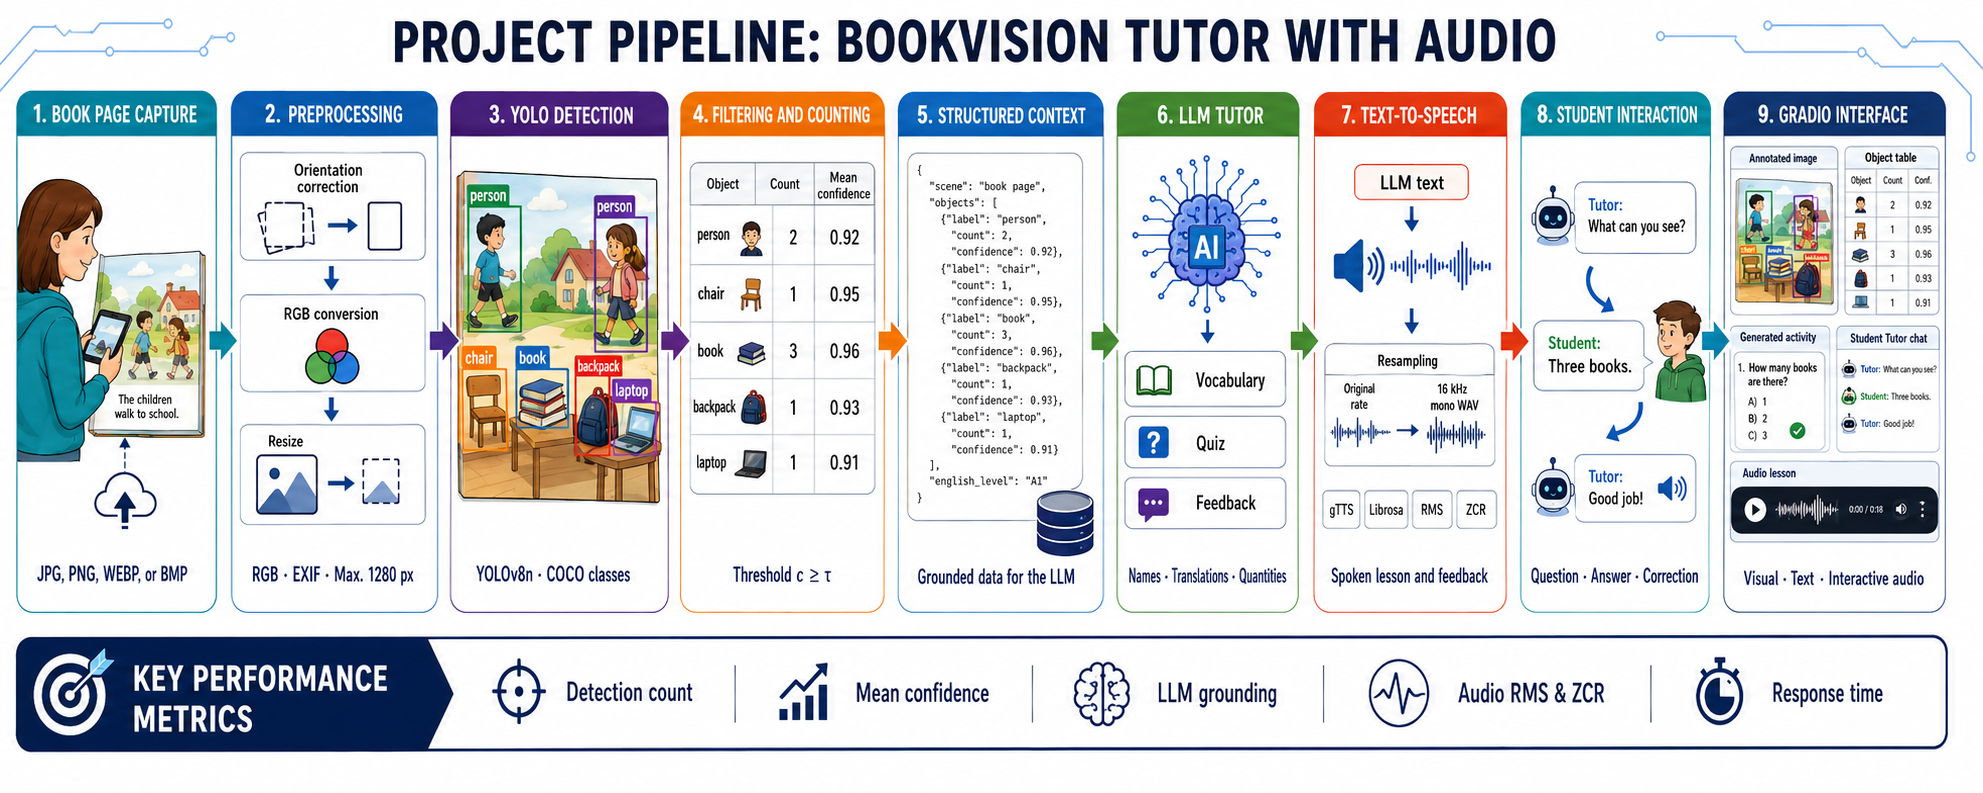

## 1 — Setup

Install the required libraries. Model weights are stored on the temporary Colab runtime disk, while inputs and outputs are stored on Google Drive.

Use a **T4 GPU** or a similar accelerator:

`Runtime > Change runtime type > T4 GPU`

In [2]:
!pip install -q -U ultralytics transformers accelerate gradio sentencepiece gTTS librosa soundfile

In [3]:
import os, json, time, random, re, uuid
from collections import Counter

import numpy as np
import pandas as pd
import torch
import librosa
import soundfile as sf
from gtts import gTTS
from PIL import Image, ImageDraw, ImageFont, ImageOps

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
INPUT_DIR = f'{DRIVE_ROOT}/BookVision_inputs'
OUTPUT_DIR = f'{DRIVE_ROOT}/L12_output'
MODEL_CACHE = '/content/models'
AUDIO_DIR = '/content/bookvision_audio'

for directory in (INPUT_DIR, OUTPUT_DIR, MODEL_CACHE, AUDIO_DIR):
    os.makedirs(directory, exist_ok=True)

os.environ['HF_HOME'] = MODEL_CACHE
os.environ['TORCH_HOME'] = MODEL_CACHE
os.environ['YOLO_CONFIG_DIR'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('GPU required. Select Runtime > Change runtime type > T4 GPU.')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def vram(tag=''):
    used = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM {used:.2f} / {total:.1f} GB  {tag}')

print('GPU:', torch.cuda.get_device_name(0))
print('Input folder:', INPUT_DIR)
print('Output folder:', OUTPUT_DIR)
vram('empty')

Mounted at /content/drive
GPU: Tesla T4
Input folder: /content/drive/MyDrive/TAE_IA_M6/BookVision_inputs
Output folder: /content/drive/MyDrive/TAE_IA_M6/L12_output
VRAM 0.00 / 15.6 GB  empty


## 2 — Upload illustrated book pages

Use pages with clear photographs or illustrations. YOLO works with COCO objects such as people, animals, vehicles, furniture, food, books, and electronic devices.

The application does **not** read paragraphs or mathematical formulas. Adding OCR would be a future extension.

In [4]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

def upload_book_pages():
    from google.colab import files
    uploaded = files.upload()
    for name, data in uploaded.items():
        if not name.lower().endswith(IMG_EXTS):
            print('Skipped unsupported file:', name)
            continue
        path = os.path.join(INPUT_DIR, name)
        with open(path, 'wb') as file:
            file.write(data)
        print('Saved:', path)

def load_book_pages(n=None):
    names = [name for name in sorted(os.listdir(INPUT_DIR))
             if name.lower().endswith(IMG_EXTS)]
    if n is not None:
        names = names[:n]
    if not names:
        raise SystemExit(f'No images in {INPUT_DIR}. Run upload_book_pages() first.')
    return {
        name: Image.open(os.path.join(INPUT_DIR, name)).copy()
        for name in names
    }

# Uncomment and run once when the folder is empty.
# upload_book_pages()

existing = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(IMG_EXTS)]
print(f'{len(existing)} book page(s) available.')

3 book page(s) available.


## 3 — Load YOLO and the local LLM

YOLO performs object detection. The LLM receives only structured detection results; it does not inspect the image directly.

Removing Stable Diffusion keeps the project small enough for a Colab T4. The selected 1.5-billion-parameter instruction model provides a practical balance between memory use and text quality.

In [5]:
from ultralytics import YOLO
from transformers import AutoTokenizer, AutoModelForCausalLM

yolo = YOLO('yolov8n.pt')
print(f'YOLO loaded: {len(yolo.names)} COCO classes')

LLM_ID = 'Qwen/Qwen2.5-1.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(LLM_ID, cache_dir=MODEL_CACHE)
llm = AutoModelForCausalLM.from_pretrained(
    LLM_ID,
    cache_dir=MODEL_CACHE,
    dtype=torch.float16,
    device_map='auto'
).eval()

vram('YOLO + LLM loaded')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/content/models/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO loaded: 80 COCO classes


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

VRAM 3.09 / 15.6 GB  YOLO + LLM loaded


## 4 — Input contract and preprocessing

Every uploaded image is converted into a valid RGB image. EXIF orientation is corrected before processing.

For an original width $W$ and height $H$, the resize scale is

$$
s=\min\left(1,\frac{M}{\max(W,H)}\right),
$$

where $M=1280$ pixels. The resized dimensions are

$$
W'=\lfloor sW\rfloor,\qquad H'=\lfloor sH\rfloor.
$$

The aspect ratio is preserved, preventing geometric distortion.

In [6]:
MAX_SIDE = 1280
MIN_SIDE = 64

def coerce_image(value):
    '''Convert a user input into a validated PIL RGB image.'''
    if value is None:
        raise ValueError('Please upload an illustrated book page.')

    if isinstance(value, np.ndarray):
        value = Image.fromarray(value.astype(np.uint8))

    if not isinstance(value, Image.Image):
        raise ValueError('Unsupported input. Use a JPG, PNG, WEBP, or BMP image.')

    image = ImageOps.exif_transpose(value).convert('RGB')
    width, height = image.size

    if min(width, height) < MIN_SIDE:
        raise ValueError(
            f'Image too small ({width}x{height}). '
            f'Use at least {MIN_SIDE}x{MIN_SIDE} pixels.'
        )

    if max(width, height) > MAX_SIDE:
        scale = MAX_SIDE / max(width, height)
        image = image.resize(
            (max(1, round(width * scale)), max(1, round(height * scale))),
            Image.Resampling.LANCZOS
        )

    return image

## 5 — YOLO detection, filtering, and counting

A detection is retained when its confidence $c_i$ satisfies

$$
c_i\geq \tau,
$$

where $\tau$ is selected in the interface. A low threshold may include false positives, while a high threshold may miss small illustrations.

For class $k$, the detected count is

$$
N_k=\sum_{i=1}^{D}\mathbb{1}(y_i=k),
$$

where $D$ is the number of retained detections and $y_i$ is the predicted class. The mean confidence is

$$
\bar{c}=\frac{1}{D}\sum_{i=1}^{D}c_i.
$$

Confidence is not the same as accuracy. True precision requires manually labelled ground truth.

In [7]:
BOX_COLORS = [
    '#16a085', '#2980b9', '#8e44ad', '#d35400', '#c0392b',
    '#2c3e50', '#27ae60', '#f39c12', '#7f8c8d', '#e84393'
]

def detect_objects(image, conf=0.25):
    '''Return retained YOLO detections, strongest first.'''
    result = yolo.predict(np.array(image), conf=float(conf), verbose=False)[0]
    detections = []

    for box in result.boxes:
        score = float(box.conf.item())
        class_id = int(box.cls.item())
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        detections.append({
            'label': result.names[class_id],
            'confidence': score,
            'box': (x1, y1, x2, y2)
        })

    return sorted(detections, key=lambda item: -item['confidence'])

def draw_detections(image, detections):
    '''Draw numbered labels without modifying the original image.'''
    annotated = image.copy()
    draw = ImageDraw.Draw(annotated)
    width = max(2, round(max(image.size) / 300))

    for index, detection in enumerate(detections, start=1):
        x1, y1, x2, y2 = detection['box']
        label = detection['label']
        score = detection['confidence']
        color = BOX_COLORS[(index - 1) % len(BOX_COLORS)]
        text = f'{index}. {label} {score:.0%}'

        draw.rectangle((x1, y1, x2, y2), outline=color, width=width)
        text_box = draw.textbbox((x1, y1), text)
        text_height = text_box[3] - text_box[1] + 6
        top = max(0, y1 - text_height)
        draw.rectangle((x1, top, x1 + text_box[2] - text_box[0] + 8, y1), fill=color)
        draw.text((x1 + 4, top + 2), text, fill='white')

    return annotated

def summarize_detections(detections):
    counts = Counter(item['label'] for item in detections)
    rows = []
    for label, count in counts.most_common():
        scores = [item['confidence'] for item in detections if item['label'] == label]
        rows.append({
            'Object': label,
            'Count': count,
            'Mean confidence': round(float(np.mean(scores)), 3)
        })
    return counts, pd.DataFrame(rows, columns=['Object', 'Count', 'Mean confidence'])

## 6 — Structured context for the LLM

The language model receives JSON instead of raw model output. This separates visual evidence from text generation.

Example:

```json
{
  "source": "illustrated book page",
  "objects": [{"name": "dog", "count": 1}],
  "english_level": "A1"
}
```

Grounding rule:

$$
\text{objects mentioned by the tutor}\subseteq\text{objects detected by YOLO}.
$$

The rule reduces hallucinations, although teacher verification is still required.

In [8]:
def build_context(counts, detections, level):
    mean_confidence = (
        float(np.mean([item['confidence'] for item in detections]))
        if detections else 0.0
    )

    return {
        'source': 'illustrated book page',
        'objects': [
            {'name': name, 'count': int(count)}
            for name, count in counts.most_common()
        ],
        'total_detections': len(detections),
        'mean_detection_confidence': round(mean_confidence, 3),
        'english_level': level,
        'grounding_rule': 'Use only the detected objects and quantities.'
    }

## 7 — Local LLM: lesson generation and tutor feedback

The LLM has two roles:

1. Generate bilingual vocabulary, a quiz, an answer key, and a speaking task.
2. Interact with the student using the same visual context.

The selected level controls language complexity:

| Level | Expected language |
|---|---|
| **A1** | Single words and short sentences |
| **A2** | Simple descriptions and comparisons |
| **B1** | Explanations, reasons, and connected sentences |

The LLM is stochastic. A fixed seed improves reproducibility, but identical wording is not guaranteed across hardware and library versions.

In [9]:
SYSTEM_PROMPT = """You are BookVision Tutor, a friendly English teacher.

Use only the object names and quantities provided in the JSON context.
Treat them as YOLO predictions, not guaranteed facts.
Never mention an object that is not present in the context.
Do not infer the location, action, purpose, or use of an object.
Do not assume that a TV shows movies or that a bed is used for sleeping.
Create questions only about object names, translations, spelling, and quantities.
Use the requested CEFR level.
Keep feedback short, supportive, and accurate.

If no objects were detected, ask the user to try a clearer illustrated page.
Teacher verification is required because YOLO and the language model can make mistakes.
"""


def clean_markdown(text):
    """Remove an optional outer Markdown code fence from an LLM response."""
    cleaned = (text or '').strip()

    if cleaned.startswith('```markdown'):
        cleaned = cleaned[len('```markdown'):].lstrip()
    elif cleaned.startswith('```'):
        cleaned = cleaned[3:].lstrip()

    if cleaned.endswith('```'):
        cleaned = cleaned[:-3].rstrip()

    return cleaned


def generate_llm(messages, max_new_tokens=420):
    """Generate one assistant response from chat-style messages."""
    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = tokenizer(prompt_text, return_tensors='pt')
    model_device = next(llm.parameters()).device
    model_inputs = {
        key: value.to(model_device)
        for key, value in model_inputs.items()
    }

    with torch.inference_mode():
        output_ids = llm.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.08,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    prompt_length = model_inputs['input_ids'].shape[1]
    generated_ids = output_ids[0, prompt_length:]
    response = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return clean_markdown(response)


def generate_lesson(context):
    request = f"""Detection context:

{json.dumps(context, ensure_ascii=False, indent=2)}

Create a compact lesson in Markdown with exactly these sections:

### Vocabulary
Create an English-Spanish table using only the detected labels.

### Quiz
Create exactly three questions. Questions may ask only about:
- detected object names;
- Spanish translations;
- spelling;
- quantities included in the JSON.

Do not ask about location, actions, purpose, or object use.
Use CEFR level {context['english_level']}.

### Answer Key
Provide three numbered answers supported directly by the JSON.

### Speaking Challenge
Ask the student to make one short sentence with a detected object word.

End with:
*AI-generated activity. Teacher verification is required.*
"""

    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': request}
    ]
    return generate_llm(messages)


def markdown_to_speech(text, max_chars=2400):
    """Convert Markdown content into short, natural text for speech."""
    spoken = clean_markdown(text)
    spoken = re.sub(r'!\[[^\]]*\]\([^)]*\)', ' ', spoken)
    spoken = re.sub(r'\[([^\]]+)\]\([^)]*\)', r'\1', spoken)
    spoken = re.sub(r'[`#*_>|~-]+', ' ', spoken)
    spoken = re.sub(r'\s+', ' ', spoken).strip()
    return spoken[:max_chars]


def text_to_speech(text, language='en'):
    """Generate a 16 kHz mono WAV file and basic audio measurements."""
    speech_text = markdown_to_speech(text)
    if not speech_text:
        raise ValueError('There is no text to convert to speech.')

    file_id = uuid.uuid4().hex[:10]
    mp3_path = os.path.join(AUDIO_DIR, f'tutor_{file_id}.mp3')
    wav_path = os.path.join(AUDIO_DIR, f'tutor_{file_id}_16k.wav')

    # gTTS creates the initial speech waveform.
    gTTS(text=speech_text, lang=language, slow=False).save(mp3_path)

    # Standardize the signal using the L13 audio workflow.
    signal, original_sr = librosa.load(mp3_path, sr=None, mono=True)
    target_sr = 16000
    if original_sr != target_sr:
        signal = librosa.resample(
            signal,
            orig_sr=original_sr,
            target_sr=target_sr
        )

    signal = signal.astype(np.float32)
    sf.write(wav_path, signal, target_sr)

    try:
        os.remove(mp3_path)
    except OSError:
        pass

    rms = float(librosa.feature.rms(y=signal).mean())
    zcr = float(librosa.feature.zero_crossing_rate(signal).mean())
    silence_pct = float((np.abs(signal) < 0.01).mean() * 100)

    stats = {
        'duration_s': round(len(signal) / target_sr, 2),
        'sample_rate_hz': target_sr,
        'samples': int(len(signal)),
        'rms_energy': round(rms, 5),
        'zero_crossing_rate': round(zcr, 5),
        'silence_pct': round(silence_pct, 2)
    }
    return wav_path, stats


def safe_text_to_speech(text):
    """Keep the vision and LLM pipeline usable if online TTS is unavailable."""
    try:
        audio_path, stats = text_to_speech(text)
        return audio_path, stats, ''
    except Exception as error:
        print(f'[text_to_speech] {type(error).__name__}: {repr(error)}')
        return None, {}, f'Audio unavailable: {type(error).__name__}'

## 8 — Complete application pipeline

`run_bookvision()` is the single entry point used by both testing and the interface. It never exposes a Python traceback to the user.

The measured runtime is

$$
T_{total}=T_{YOLO}+T_{LLM}+T_{other}.
$$

On a T4, YOLO is normally much faster than local text generation, so the LLM usually dominates total latency.

In [10]:
def run_bookvision(value, level='A1', conf=0.25):
    """Return annotated image, table, lesson, context, and status message."""
    empty = pd.DataFrame(columns=['Object', 'Count', 'Mean confidence'])

    try:
        image = coerce_image(value)
    except ValueError as error:
        return None, empty, '', {}, str(error)

    try:
        start = time.time()
        detections = detect_objects(image, conf)
        yolo_time = time.time() - start

        annotated = draw_detections(image, detections)
        counts, table = summarize_detections(detections)
        context = build_context(counts, detections, level)

        start = time.time()
        lesson = generate_lesson(context)
        llm_time = time.time() - start

        status = (
            f'Detections: {len(detections)} | '
            f'YOLO: {yolo_time:.2f} s | LLM: {llm_time:.2f} s | '
            f'Level: {level}'
        )
        if not detections:
            status += ' | No COCO objects detected.'

        return annotated, table, lesson, context, status

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return None, empty, '', {}, 'GPU memory error. Try a smaller image.'
    except Exception as error:
        import traceback
        print(f'[run_bookvision] {type(error).__name__}: {repr(error)}')
        traceback.print_exc()
        return (
            None,
            empty,
            '',
            {},
            f'Pipeline error: {type(error).__name__}. Check the traceback above.'
        )

## 9 — Test before launching the interface

Predict which objects YOLO will detect before running this section. Compare your prediction with the output and look for false positives or missed illustrations.

The hostile-input tests must produce readable messages instead of tracebacks.

--- detection test on 3 page(s) ---
07_cats&dogs.png         -> dog 0.94, bench 0.92, person 0.88, cat 0.66, bird 0.62, dog 0.46
08_street.png            -> bus 0.94, bicycle 0.92, car 0.91, person 0.87, traffic light 0.87, bicycle 0.70
09_classroom.png         -> chair 0.93, chair 0.89, chair 0.83, person 0.79, laptop 0.78, backpack 0.56

--- hostile inputs ---
None       -> Please upload an illustrated book page.
1x1        -> Image too small (1x1). Use at least 64x64 pixels.
grayscale  -> accepted as RGB, size (1254, 1254)
RGBA       -> accepted as RGB, size (1254, 1254)

--- complete pipeline ---
Page: 07_cats&dogs.png
Detections: 6 | YOLO: 0.05 s | LLM: 24.08 s | Level: A1


,Object,Count,Mean confidence
0,dog,2,0.701
1,bench,1,0.924
2,person,1,0.880
3,cat,1,0.660
4,bird,1,0.616


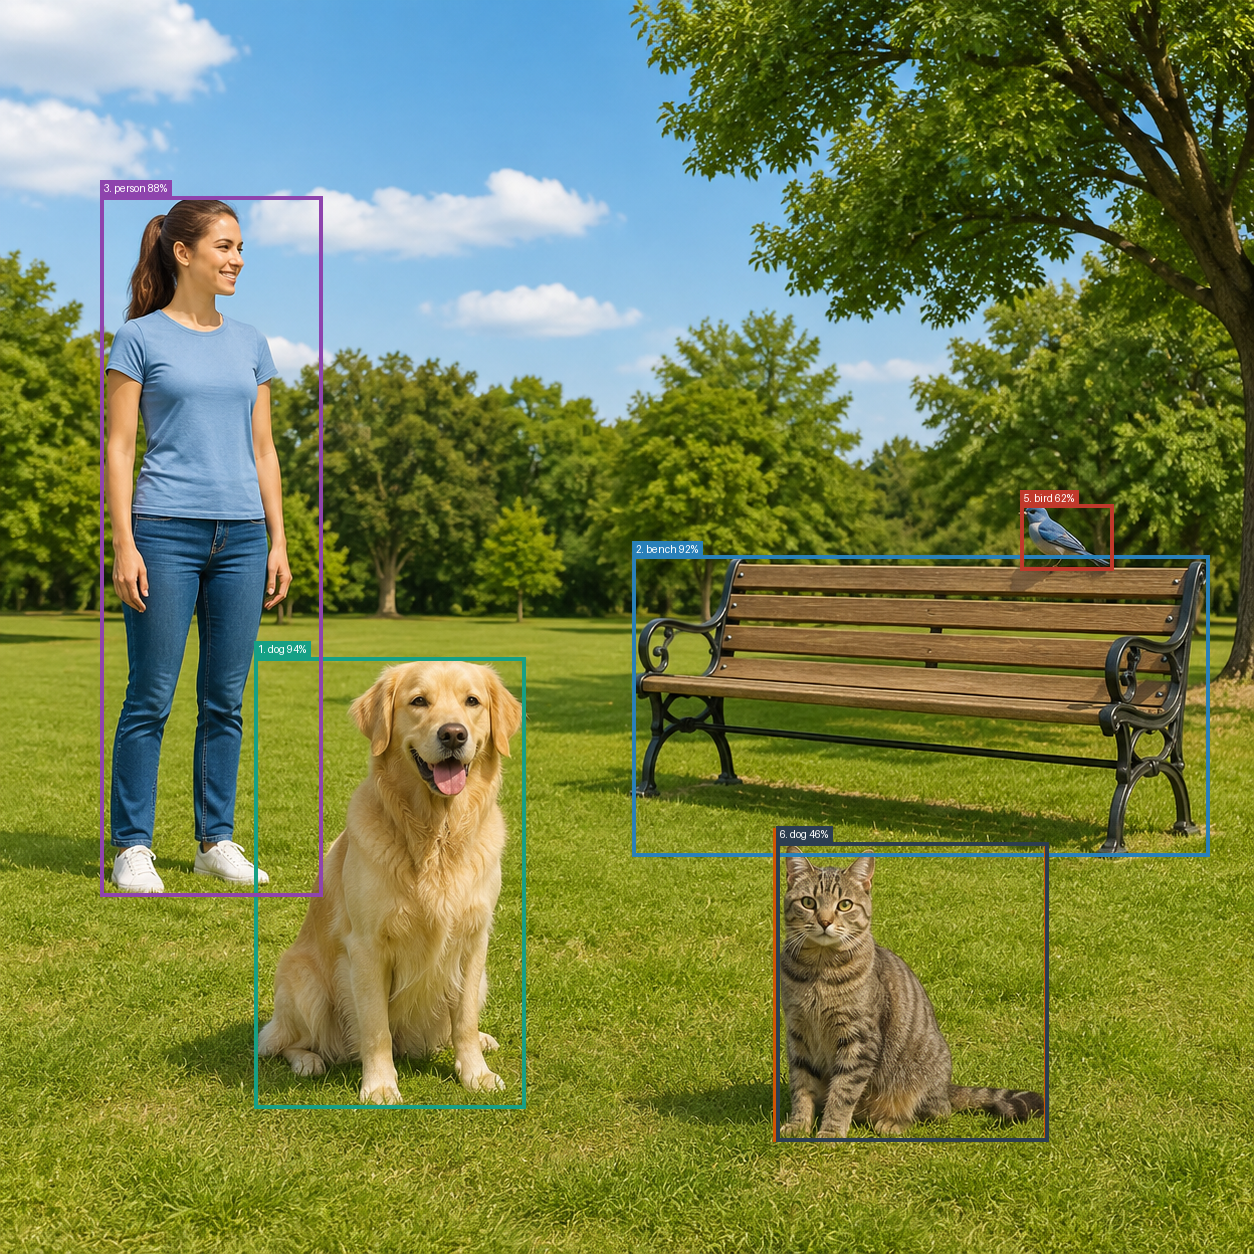

Saved: /content/drive/MyDrive/TAE_IA_M6/L12_output/07_cats&dogs_annotated.jpg


### Vocabulary

| English | Spanish |
|---------|---------|
| dog     | perro   |
| bench   | mesa   |
| person  | persona|
| cat     | gato    |
| bird    | pájaro  |

### Quiz

1. What is the name of the animal you see?
2. How many benches did we detect?
3. How many cats did we see?

### Answer Key

1. The animal I saw is a **perro** (dog).
2. We detected **una mesa** (a bench) once.
3. There was **un gato** (a cat).

### Speaking Challenge

Make a sentence using the word "bench" from the detection.

*AI-generated activity. Teacher verification is required.*


--- generated tutor audio ---


{'duration_s': 43.42,
 'sample_rate_hz': 16000,
 'samples': 694656,
 'rms_energy': 0.07818,
 'zero_crossing_rate': 0.14012,
 'silence_pct': 40.15}

VRAM 3.13 / 15.6 GB  pipeline test


In [11]:
from IPython.display import Markdown, Audio, display

pages = load_book_pages(n=5)

print(f'--- detection test on {len(pages)} page(s) ---')
for name, page in pages.items():
    image = coerce_image(page)
    detections = detect_objects(image, conf=0.25)
    result = ', '.join(
        f"{item['label']} {item['confidence']:.2f}"
        for item in detections[:6]
    ) or 'NO COCO OBJECTS DETECTED'
    print(f'{name[:24]:24s} -> {result}')

print('\n--- hostile inputs ---')
for tag, value in [
    ('None', None),
    ('1x1', Image.new('RGB', (1, 1))),
    ('grayscale', next(iter(pages.values())).convert('L')),
    ('RGBA', next(iter(pages.values())).convert('RGBA')),
]:
    try:
        validated = coerce_image(value)
        message = f'accepted as {validated.mode}, size {validated.size}'
    except ValueError as error:
        message = str(error)
    print(f'{tag:10s} -> {message[:90]}')

test_name, test_page = next(iter(pages.items()))
annotated, table, lesson, context, status = run_bookvision(
    test_page, level='A1', conf=0.25
)

print('\n--- complete pipeline ---')
print('Page:', test_name)
print(status)
display(table)

if annotated is not None:
    display(annotated)
    save_path = os.path.join(
        OUTPUT_DIR,
        f"{os.path.splitext(test_name)[0]}_annotated.jpg"
    )
    annotated.save(save_path)
    print('Saved:', save_path)
else:
    print('Annotated image was not saved because the pipeline failed.')

if lesson:
    display(Markdown(clean_markdown(lesson)))

    audio_path, audio_stats, audio_warning = safe_text_to_speech(lesson)
    if audio_path:
        print('\n--- generated tutor audio ---')
        display(audio_stats)
        display(Audio(audio_path))
    else:
        print(audio_warning)
else:
    print('No lesson was generated.')

vram('pipeline test')

## 10 — Gradio interface, interactive tutor, and audio

The interface contains three connected actions:

- **Analyze Page:** runs YOLO, creates the lesson, and generates its audio.
- **Send:** sends the student's written response to the LLM.
- **Tutor Audio:** plays the latest lesson or feedback at 16000 Hz.

The generated signal is standardized with the L13 resampling relation

$$
N_{new}\approx N_{original}\frac{f_{new}}{f_{original}},
$$

where $f_{new}=16000$ Hz. Its RMS energy is

$$
\operatorname{RMS}=\sqrt{\frac{1}{N}\sum_{n=0}^{N-1}x[n]^2}.
$$

The interface also reports duration, sample count, RMS energy, zero-crossing rate, and silence percentage. `gr.State` preserves the YOLO context during the conversation. Audio generation uses an online TTS service; if it is temporarily unavailable, detection, lesson generation, and chat remain operational.

### Deterministic quantity validation

Numerical answers are checked in Python before the LLM is called. For a detected class $k$, let $N_k$ be the YOLO count and let $A_k$ be the quantity written by the student. The decision is

$$
\operatorname{correct}(A_k)=
\begin{cases}
1, & A_k=N_k,\\
0, & A_k\neq N_k.
\end{cases}
$$

For example, when YOLO reports two books and the student writes `There are three books`, the application returns `Incorrect. There are two books.` This direct comparison prevents the LLM from accepting two different quantities as correct. Open-ended questions, translations, and explanations continue to use the LLM.

In [12]:
import gradio as gr
import traceback


try:
    gr.close_all()
except Exception:
    pass



NUMBER_WORDS = {
    'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9,
    'ten': 10, 'eleven': 11, 'twelve': 12, 'thirteen': 13,
    'fourteen': 14, 'fifteen': 15, 'sixteen': 16,
    'seventeen': 17, 'eighteen': 18, 'nineteen': 19,
    'twenty': 20
}

IRREGULAR_PLURALS = {
    'person': 'people',
    'mouse': 'mice'
}


def number_to_words(number):
    """Convert an integer from 0 to 20 into an English word."""
    for word, value in NUMBER_WORDS.items():
        if value == number:
            return word
    return str(number)


def pluralize(label, count):
    """Return a simple singular or plural COCO label."""
    if count == 1:
        return label
    if label in IRREGULAR_PLURALS:
        return IRREGULAR_PLURALS[label]
    if label.endswith(('s', 'x', 'z', 'ch', 'sh')):
        return label + 'es'
    if label.endswith('y') and len(label) > 1 and label[-2] not in 'aeiou':
        return label[:-1] + 'ies'
    return label + 's'


def object_aliases(label):
    """Return forms that a student may use for one detected label."""
    aliases = {label, pluralize(label, 2)}
    if label == 'person':
        aliases.update({'person', 'people'})
    return aliases


def extract_number(text):
    """Extract the first integer or English number word."""
    normalized = text.lower()
    digit_match = re.search(r'\b\d+\b', normalized)
    if digit_match:
        return int(digit_match.group())

    for word, value in NUMBER_WORDS.items():
        if re.search(rf'\b{re.escape(word)}\b', normalized):
            return value
    return None


def extract_object(text, context):
    """Find the detected object named in a student response."""
    normalized = text.lower()
    objects = sorted(
        context.get('objects', []),
        key=lambda item: len(item.get('name', '')),
        reverse=True
    )

    for item in objects:
        label = str(item.get('name', '')).lower().strip()
        for alias in object_aliases(label):
            if alias and re.search(rf'\b{re.escape(alias)}\b', normalized):
                return label
    return None


def expected_count(label, context):
    """Return the YOLO count for one label."""
    for item in context.get('objects', []):
        if str(item.get('name', '')).lower() == label.lower():
            return int(item.get('count', 0))
    return None


def check_count_answer(student_text, context):
    """Compare a stated quantity with the structured YOLO context."""
    student_count = extract_number(student_text)
    object_label = extract_object(student_text, context)

    if student_count is None or object_label is None:
        return None, None

    correct_count = expected_count(object_label, context)
    if correct_count is None:
        return None, None

    verb = 'is' if correct_count == 1 else 'are'
    correct_phrase = (
        f'There {verb} {number_to_words(correct_count)} '
        f'{pluralize(object_label, correct_count)}.'
    )

    if student_count == correct_count:
        return f'Correct! {correct_phrase}', True
    return f'Incorrect. {correct_phrase}', False


def analyze_for_app(image, level, conf):

    """Run vision, lesson generation, and speech synthesis."""
    try:
        annotated, table, lesson, context, status = run_bookvision(
            image,
            level=level,
            conf=float(conf)
        )

        table_output = (
            table.values.tolist()
            if isinstance(table, pd.DataFrame)
            else (table or [])
        )
        lesson_output = clean_markdown(lesson)

        if context:
            welcome = (
                f'I analyzed the page at level {level}. '
                'Read or listen to the activity, then answer a question.'
            )
            chat_history = [
                {'role': 'assistant', 'content': welcome}
            ]
        else:
            chat_history = []

        audio_path, audio_stats, audio_warning = safe_text_to_speech(
            lesson_output
        )
        if audio_warning:
            status = f'{status} | {audio_warning}'
        elif audio_path:
            status = f'{status} | Audio ready'

        return (
            annotated,
            table_output,
            lesson_output,
            status,
            context,
            chat_history,
            audio_path,
            audio_stats
        )

    except Exception as error:
        print(f'[analyze_for_app] {type(error).__name__}: {repr(error)}')
        traceback.print_exc()
        return (
            None,
            [],
            '### Analysis failed\nCheck the Colab output.',
            f'Interface error: {type(error).__name__}: {str(error)}',
            {},
            [],
            None,
            {}
        )


def history_to_messages(history):
    """Validate Gradio messages before passing them to the LLM."""
    valid_messages = []
    for message in (history or [])[-8:]:
        if not isinstance(message, dict):
            continue
        role = message.get('role')
        content = message.get('content')
        if role in ('user', 'assistant') and isinstance(content, str):
            if content.strip():
                valid_messages.append({
                    'role': role,
                    'content': content.strip()
                })
    return valid_messages


def tutor_reply(message, history, context):
    """Check exact quantities, then use the LLM for open responses."""
    history = history_to_messages(history)

    if not message or not message.strip():
        return '', history, None, {}

    student_text = message.strip()

    if not context:
        answer = 'Please analyze a book page before starting the lesson.'
        history.extend([
            {'role': 'user', 'content': student_text},
            {'role': 'assistant', 'content': answer}
        ])
        audio_path, audio_stats, _ = safe_text_to_speech(answer)
        return '', history, audio_path, audio_stats

    # Quantity answers are validated directly against YOLO's JSON context.
    feedback, is_correct = check_count_answer(student_text, context)
    if feedback is not None:
        history.extend([
            {'role': 'user', 'content': student_text},
            {'role': 'assistant', 'content': feedback}
        ])
        audio_path, audio_stats, _ = safe_text_to_speech(feedback)
        return '', history, audio_path, audio_stats

    # The LLM handles translations, spelling, explanations, and open answers.
    conversation = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {
            'role': 'user',
            'content': (
                'Use this detection context for the entire conversation:\n' +
                json.dumps(context, ensure_ascii=False)
            )
        },
        {
            'role': 'assistant',
            'content': 'I will use only the detected labels and quantities.'
        }
    ]
    conversation.extend(history)
    conversation.append({'role': 'user', 'content': student_text})

    try:
        answer = clean_markdown(
            generate_llm(conversation, max_new_tokens=180)
        )
    except Exception as error:
        print(f'[tutor_reply] {type(error).__name__}: {repr(error)}')
        traceback.print_exc()
        answer = 'I could not generate feedback. Please try again.'

    history.extend([
        {'role': 'user', 'content': student_text},
        {'role': 'assistant', 'content': answer}
    ])
    audio_path, audio_stats, _ = safe_text_to_speech(answer)
    return '', history, audio_path, audio_stats


def clear_interface():
    return None, [], '', '', {}, [], '', None, {}


with gr.Blocks(title='BookVision Tutor with Audio') as app:
    gr.Markdown(
        '# BookVision Tutor with Audio\n'
        'Upload an illustrated page. YOLO detects objects, the LLM creates an '
        'English activity, and Text-to-Speech reads the tutor response aloud.'
    )

    context_state = gr.State({})

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(type='pil', label='Illustrated book page')
            level = gr.Dropdown(
                choices=['A1', 'A2', 'B1'],
                value='A1',
                label='English level'
            )
            confidence = gr.Slider(
                minimum=0.10,
                maximum=0.70,
                value=0.25,
                step=0.05,
                label='Detection confidence'
            )
            with gr.Row():
                analyze_button = gr.Button('Analyze Page', variant='primary')
                clear_button = gr.Button('Clear')

        with gr.Column():
            annotated_output = gr.Image(label='YOLO detections')
            object_table = gr.Dataframe(
                headers=['Object', 'Count', 'Mean confidence'],
                datatype=['str', 'number', 'number'],
                interactive=False,
                label='Detected objects'
            )
            status_output = gr.Textbox(label='Pipeline status', lines=2)

    with gr.Row():
        with gr.Column():
            gr.Markdown('### Generated activity')
            lesson_output = gr.Markdown()

        with gr.Column():
            chatbot = gr.Chatbot(label='Student Tutor', height=420)
            student_message = gr.Textbox(
                label='Your answer or question',
                placeholder='Example: I can see three books.'
            )
            send_button = gr.Button('Send', variant='primary')

    with gr.Row():
        audio_output = gr.Audio(
            label='Tutor audio',
            type='filepath'
        )
        audio_stats_output = gr.JSON(label='Audio properties')

    analyze_button.click(
        fn=analyze_for_app,
        inputs=[input_image, level, confidence],
        outputs=[
            annotated_output,
            object_table,
            lesson_output,
            status_output,
            context_state,
            chatbot,
            audio_output,
            audio_stats_output
        ]
    )

    send_button.click(
        fn=tutor_reply,
        inputs=[student_message, chatbot, context_state],
        outputs=[
            student_message,
            chatbot,
            audio_output,
            audio_stats_output
        ]
    )

    student_message.submit(
        fn=tutor_reply,
        inputs=[student_message, chatbot, context_state],
        outputs=[
            student_message,
            chatbot,
            audio_output,
            audio_stats_output
        ]
    )

    clear_button.click(
        fn=clear_interface,
        inputs=None,
        outputs=[
            input_image,
            object_table,
            lesson_output,
            status_output,
            context_state,
            chatbot,
            student_message,
            audio_output,
            audio_stats_output
        ]
    )

app.queue().launch(share=True, quiet=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://012fa60ffafdaeb926.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 11 — Evaluation and critical analysis

### 11.1 Detection metrics

For a labelled evaluation set, object-detection precision and recall are

$$
\text{Precision}=\frac{TP}{TP+FP},
\qquad
\text{Recall}=\frac{TP}{TP+FN}.
$$

The Intersection over Union between predicted box $B_p$ and ground-truth box $B_g$ is

$$
\operatorname{IoU}(B_p,B_g)=
\frac{|B_p\cap B_g|}{|B_p\cup B_g|}.
$$

`mAP50` requires multiple labelled images and treats a matched prediction as correct when $\operatorname{IoU}\geq0.50$. It cannot be calculated honestly from one unlabelled uploaded page.

### 11.2 LLM grounding fidelity

A simple manual grounding score is

$$
F_{ground}=\frac{\text{supported object claims}}
{\text{all object claims generated by the LLM}}.
$$

A target of $F_{ground}=1$ means that every object claim is supported by YOLO's structured context. This does not guarantee that YOLO itself was correct.

### 11.3 Limitations

- YOLO recognises only the 80 COCO classes.
- Stylised or small book illustrations may be missed.
- Similar shapes may create false positives.
- The LLM may produce an unsupported statement despite its prompt.
- The application does not read printed text or formulas.
- Teacher verification is required before using generated material in class.

### 11.4 Responsible use

The application analyses book illustrations, not student identity or performance. It must not infer personal characteristics from detected people. Generated activities are instructional drafts, not formal assessments.

### 11.5 Audio measurements

The tutor audio is converted to mono and resampled to 16000 Hz. The interface reports RMS energy, zero-crossing rate, and silence percentage. These measurements describe the generated waveform; they do not measure pronunciation quality or student learning.

Because gTTS is an online service, audio generation can fail when the runtime has no external connection. `safe_text_to_speech()` isolates that failure so the visual and language pipeline remains available.

### 11.6 Answer-validation boundary

Exact quantity checks are deterministic and do not depend on language-model judgement. Their correctness still depends on YOLO's count: if YOLO misses an object or produces a duplicate detection, the tutor will use that incorrect count. For this reason, the annotated image and object table should be reviewed before the student begins the activity.

## 12 — Cleanup from the vision track

Run this section only after reviewing the old model folder. Nothing is deleted while `CONFIRM = False`.

The project inputs and BookVision outputs are kept. Only the legacy `TAE_IA_M6/models` folder is eligible for removal.

In [13]:
import shutil

LEGACY = f'{DRIVE_ROOT}/models'

def folder_gb(path):
    if not os.path.exists(path):
        return 0.0
    return sum(
        os.path.getsize(os.path.join(root, filename))
        for root, _, filenames in os.walk(path)
        for filename in filenames
    ) / 1e9

if os.path.exists(LEGACY):
    print(f'Legacy folder: {LEGACY} ({folder_gb(LEGACY):.2f} GB)')
    for entry in sorted(os.listdir(LEGACY)):
        entry_path = os.path.join(LEGACY, entry)
        print(f'{folder_gb(entry_path):6.2f} GB  {entry}')

    CONFIRM = False
    if CONFIRM:
        freed = folder_gb(LEGACY)
        shutil.rmtree(LEGACY)
        print(f'Freed {freed:.2f} GB.')
    else:
        print('Review the list. Change CONFIRM to True only when ready.')
else:
    print('No legacy model folder was found.')

print('BookVision inputs kept:', os.path.exists(INPUT_DIR))
print('BookVision outputs kept:', os.path.exists(OUTPUT_DIR))

Legacy folder: /content/drive/MyDrive/TAE_IA_M6/models (18.50 GB)
  0.00 GB  .agent_harnesses.json
 14.98 GB  blip2-opt-2.7b-local
  0.61 GB  clip-vit-base-patch32-local
  0.03 GB  fast_neural_style
  0.13 GB  lcm-lora-sdv1-5-local
  2.74 GB  sd15-local
  0.00 GB  torch_home
Review the list. Change CONFIRM to True only when ready.
BookVision inputs kept: True
BookVision outputs kept: True


---

## Conclusion

BookVision Tutor demonstrates a grounded multimodal application:

1. YOLO converts visual content into structured detections.
2. The LLM converts those detections into level-appropriate educational material.
3. Gradio lets the student receive feedback through an interactive conversation.

The strongest design choice is the explicit boundary between visual evidence and language generation. This makes the pipeline easier to test, explain, and improve.

*TAE-IA · Module 6 · L12 · BookVision Tutor*